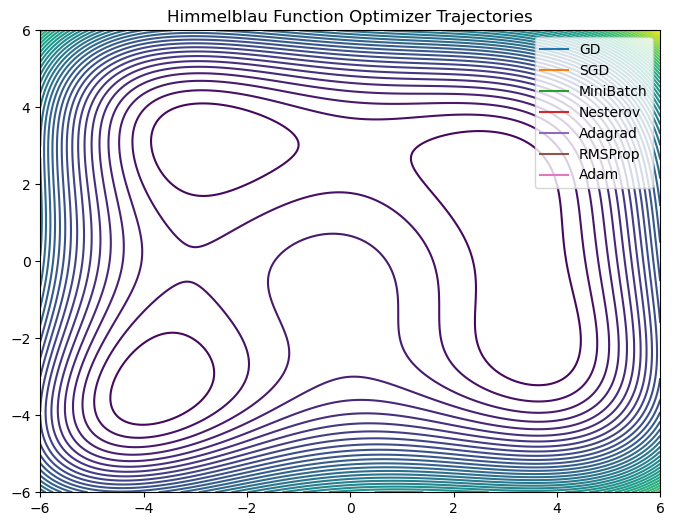

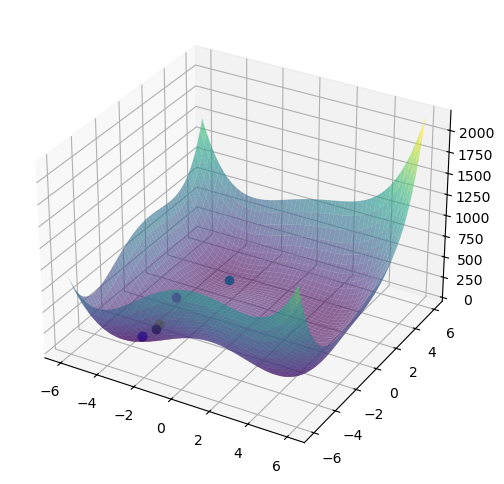

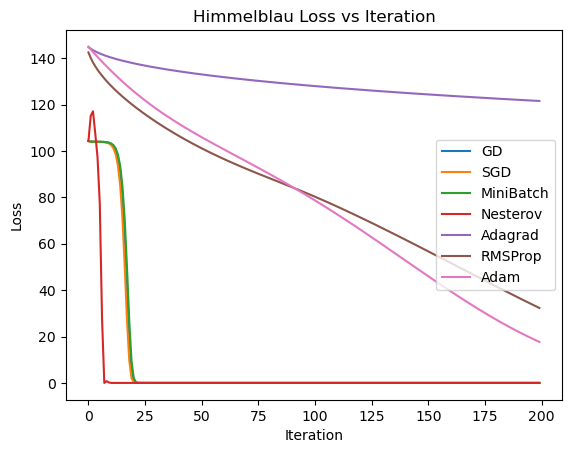

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# ===================== PART 1: HIMMELBLAU FUNCTION =====================

def himmelblau(w):
    w1, w2 = w
    return (w1**2 + w2 - 11)**2 + (w1 + w2**2 - 7)**2

def grad_himmelblau(w):
    w1, w2 = w
    df_dw1 = 4*w1*(w1**2 + w2 - 11) + 2*(w1 + w2**2 - 7)
    df_dw2 = 2*(w1**2 + w2 - 11) + 4*w2*(w1 + w2**2 - 7)
    return np.array([df_dw1, df_dw2])

# ===================== OPTIMIZER ENGINE =====================

def run_optimizer(f, grad, w_init, name,
                  lr=0.01, iters=200,
                  beta1=0.9, beta2=0.999):
    w = w_init.copy()
    history = []
    v = np.zeros_like(w)
    G = np.zeros_like(w)
    m = np.zeros_like(w)
    Eg = np.zeros_like(w)

    for t in range(1, iters+1):
        if name == "SGD":
            g = grad(w) + np.random.normal(0,0.1,w.shape)
        else:
            g = grad(w)

        if name in ["GD","SGD"]:
            w -= lr * g
        elif name == "MiniBatch":
            g = grad(w) + np.random.normal(0,0.05,w.shape)
            w -= lr*g
        elif name == "Nesterov":
            lookahead = w - beta1*v
            g = grad(lookahead)
            v = beta1*v + lr*g
            w -= v
        elif name == "Adagrad":
            G += g**2
            w -= lr*g/(np.sqrt(G)+1e-8)
        elif name == "RMSProp":
            Eg = beta1*Eg + (1-beta1)*g**2
            w -= lr*g/(np.sqrt(Eg)+1e-8)
        elif name == "Adam":
            m = beta1*m + (1-beta1)*g
            v = beta2*v + (1-beta2)*(g**2)
            m_hat = m/(1-beta1**t)
            v_hat = v/(1-beta2**t)
            w -= lr*m_hat/(np.sqrt(v_hat)+1e-8)
        history.append((w.copy(), f(w)))
    return history

optimizers = ["GD","SGD","MiniBatch","Nesterov","Adagrad","RMSProp","Adam"]

# ===================== PART 1 RUN =====================

w0 = np.array([-4.0,0.0])
results_part1 = {}
iters=200

for opt in optimizers:
    results_part1[opt] = run_optimizer(himmelblau, grad_himmelblau, w0, opt, lr=0.01, iters=iters)

# ===================== PART 1 VISUALIZATION =====================

x = np.linspace(-6,6,400)
y = np.linspace(-6,6,400)
X, Y = np.meshgrid(x,y)
Z = himmelblau(np.array([X,Y]))

# Animated 2D contour
fig, ax = plt.subplots(figsize=(8,6))
ax.contour(X,Y,Z, levels=50)
lines = {opt: ax.plot([],[],label=opt)[0] for opt in optimizers}
points = {opt: ax.plot([],[], 'o')[0] for opt in optimizers}
ax.legend()
ax.set_title("Himmelblau Function Optimizer Trajectories")

data_traj = {opt: np.array([h[0] for h in results_part1[opt]]) for opt in optimizers}

def init():
    for opt in optimizers:
        lines[opt].set_data([],[])
        points[opt].set_data([],[])
    return list(lines.values()) + list(points.values())

def animate(i):
    for opt in optimizers:
        traj = data_traj[opt]
        lines[opt].set_data(traj[:i,0], traj[:i,1])
        points[opt].set_data(traj[i-1,0], traj[i-1,1])
    return list(lines.values()) + list(points.values())

ani = animation.FuncAnimation(fig, animate, frames=iters, init_func=init, interval=50, blit=True)
plt.show()

# 3D Surface Animation
fig3d = plt.figure(figsize=(8,6))
ax3d = fig3d.add_subplot(111, projection='3d')
ax3d.plot_surface(X,Y,Z, cmap='viridis', alpha=0.6)
colors = ['r','g','b','c','m','y','k']
points3d = [ax3d.plot([],[],[], 'o', color=colors[i])[0] for i in range(len(optimizers))]

def animate3d(i):
    for idx,opt in enumerate(optimizers):
        traj = data_traj[opt]
        points3d[idx].set_data([traj[i-1,0]], [traj[i-1,1]])
        points3d[idx].set_3d_properties([himmelblau(traj[i-1])])
    return points3d

ani3d = animation.FuncAnimation(fig3d, animate3d, frames=iters, interval=50, blit=True)
plt.show()

# Loss vs iteration plot
plt.figure()
for opt in optimizers:
    losses = [h[1] for h in results_part1[opt]]
    plt.plot(losses,label=opt)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Himmelblau Loss vs Iteration")
plt.legend()
plt.show()

# ===================== PART 2: LOGISTIC REGRESSION =====================

# Load MNIST CSV dataset with no header (since your file doesn't have column names)
data = pd.read_csv(r"C:\Users\23adsb48\Downloads\MNIST_CSV\mnist_train.csv", header=None)

# First column is labels
y = data.iloc[:, 0].values

# Remaining columns are pixels/features
X_pixels = data.iloc[:, 1:].values

# Reduce 784 pixels to 2 features using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(X_pixels)

def sigmoid(z):
    z = np.clip(z, -500, 500)  # clip inputs to avoid overflow
    return 1 / (1 + np.exp(-z))

def logistic_loss(w):
    z = X @ w
    y_hat = sigmoid(z)
    return -np.mean(y*np.log(y_hat+1e-8)+(1-y)*np.log(1-y_hat+1e-8))

def logistic_grad(w):
    z = X @ w
    y_hat = sigmoid(z)
    return (1/len(y))*X.T @ (y_hat - y)

# Run optimizers for logistic regression
w0 = np.zeros(2)
results_part2 = {}
iters2=200

for opt in optimizers:
    results_part2[opt] = run_optimizer(logistic_loss, logistic_grad, w0, opt, lr=0.1, iters=iters2)

# Animated 2D contour for logistic regression
x2 = np.linspace(X[:,0].min()-0.1,X[:,0].max()+0.1,200)
y2 = np.linspace(X[:,1].min()-0.1,X[:,1].max()+0.1,200)
X2, Y2 = np.meshgrid(x2,y2)
Z2 = np.zeros_like(X2)
for i in range(X2.shape[0]):
    for j in range(X2.shape[1]):
        w_temp = np.array([X2[i,j], Y2[i,j]])
        Z2[i,j] = logistic_loss(w_temp)

fig2, ax2 = plt.subplots(figsize=(8,6))
ax2.contour(X2,Y2,Z2, levels=50)
lines2 = {opt: ax2.plot([],[],label=opt)[0] for opt in optimizers}
points2 = {opt: ax2.plot([],[], 'o')[0] for opt in optimizers}
ax2.legend()
ax2.set_title("Logistic Regression Optimizer Trajectories")

data_traj2 = {opt: np.array([h[0] for h in results_part2[opt]]) for opt in optimizers}

def init2():
    for opt in optimizers:
        lines2[opt].set_data([],[])
        points2[opt].set_data([],[])
    return list(lines2.values()) + list(points2.values())

def animate2(i):
    for opt in optimizers:
        traj = data_traj2[opt]
        lines2[opt].set_data(traj[:i,0], traj[:i,1])
        points2[opt].set_data(traj[i-1,0], traj[i-1,1])
    return list(lines2.values()) + list(points2.values())

ani2 = animation.FuncAnimation(fig2, animate2, frames=iters2, init_func=init2, interval=50, blit=True)
plt.show()

# Loss vs iteration plot for logistic regression
plt.figure()
for opt in optimizers:
    losses2 = [h[1] for h in results_part2[opt]]
    plt.plot(losses2,label=opt)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Logistic Regression Loss vs Iteration")
plt.legend()
plt.show()
